# Implementing the KDD Methods

This notebook tests the methods in the KDD 2025 survey by Liu and Cui,
*Data Heterogeneity Modeling for Trustworthy Machine Learning*, on COMPAS.

**HRM** (Heterogeneous Risk Minimization) tries to find hidden subpopulations and the features
that behave differently in each, by alternating between the two.

**Predictive heterogeneity** asks how much extra predictive power you unlock by splitting the
data, if you split it in the best possible way.

**Relative regret** asks how much worse the single global model is on a group than that group's
own model would be.

Each method is run on three synthetic datasets where the ground truth is known, so a method's
answer can be marked right or wrong, and then on real COMPAS.

## Part 0. Setup and the three synthetic datasets

The synthetic datasets keep the real features and replace the labels. A boosted model fit to the
real outcome supplies a realistic base logit, and a coefficient flip is planted (or not) on top of it.

1. **A**. Everyone follows the same rule. No flip exists.
2. **B**. `priors_count` works backwards for the under 25s. A flip inside a demographic cell.
3. **C**. `priors_count` works backwards for the longest 20% of stays. A flip that cuts *across* demographics.

In all three, the correct answer for every feature except `priors_count` is "not variant".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
SEED = 42

In [2]:
df = pd.read_csv("clean-compas-scores-two-year.csv")
df["sex_male"] = (df["sex"] == "Male").astype(int)
df["charge_felony"] = (df["c_charge_degree"] == "F").astype(int)
df["race_age"] = df["race_for_model"] + " / " + df["age_cat"]

FEATURES = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count",
            "len_of_stay", "days_b_screening_arrest", "sex_male", "charge_felony"]
X = df[FEATURES]; Xv = X.values
Xs = StandardScaler().fit_transform(X)
groups = df["race_age"]
y_real = df["two_year_recid"].values
J = FEATURES.index("priors_count")

# base logit. a boosted model fit to the real labels, with predictions taken out of fold so
# the logit is not a memorized copy of y. plain sklearn GBT, no extra dependency needed.
gbm = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                 subsample=0.8, random_state=SEED)
p_gen = np.clip(cross_val_predict(gbm, Xv, y_real, cv=5, method="predict_proba")[:, 1], 1e-6, 1-1e-6)
LOGIT = np.log(p_gen / (1 - p_gen))

# BETA_P is the real data logistic coefficient of priors on standardized features.
# subtracting 2 * BETA_P * x_priors inside a group flips the sign of the priors effect there.
BETA_P = LogisticRegression(max_iter=3000).fit(Xs, y_real).coef_[0][J]
GROUP_B = (df["age_cat"] == "Less than 25").values
GROUP_C = (df["len_of_stay"] >= df["len_of_stay"].quantile(0.80)).values

def make_synthetic(which, rng):
    rule = LOGIT.copy()
    if which == "B": rule = rule - 2 * BETA_P * Xs[:, J] * GROUP_B
    if which == "C": rule = rule - 2 * BETA_P * Xs[:, J] * GROUP_C
    return rng.binomial(1, 1 / (1 + np.exp(-rule)))

print(f"n = {len(df)} | BETA_P = {BETA_P:.3f} | under 25 share = {GROUP_B.mean():.0%} | "
      f"long stay share = {GROUP_C.mean():.0%}")

n = 6172 | BETA_P = 0.754 | under 25 share = 22% | long stay share = 21%


## Part 1. HRM (Heterogeneous Risk Minimization)

Reimplemented from **github.com/LJSthu/HRM** (Jiashuo Liu, first author of the survey).

What it does, from their `Frontend.py` and `Backend.py`.

The **frontend** (`McModel.cluster`) fits a linear model per cluster, then assigns each person to
the cluster whose model has the smallest error on their own label, that is
`new_domain = argmin_k |X @ coef_k + bias_k - y|`, and repeats until few people move.

The **backend** (`MpModel.single_iter_mip`) takes, for each environment, the gradient of the loss
with respect to the model weights. `penalty_j` is the spread across environments of feature *j*'s
gradient. Features with unstable gradients get their selection gate pushed down.

Two notes on scope and faithfulness.

1. Their code is `LinearRegression` with `nn.MSELoss()` throughout, so running HRM on the binary
   `two_year_recid` is running it outside its stated scope. Part 1 does it anyway (that is what
   applying the survey to COMPAS means), then repeats the test with a continuous outcome, which is
   the fair setting.
2. In their `single_iter_mip` the gated input is detached when the penalty is formed, so the
   gradient of the penalty with respect to gate *j* is `penalty_j` itself, and the final feature
   ranking is the ranking by `penalty_j`. The penalty is therefore computed in closed form below
   instead of rerunning their Adam loop. For a linear model with MSE, feature *j*'s gradient in an
   environment is just the mean over that environment of `x_ij * (prediction_i - y_i)`.

In [6]:
def hrm_frontend(D, y, K=3, max_iter=30, delta_frac=0.04, seed=0, weight=None):
    # their McModel.cluster. per cluster least squares, then reassign each person to the
    # cluster whose model best predicts their own label.
    rng = np.random.default_rng(seed)
    n, d = D.shape
    Dw = D * weight[None, :] if weight is not None else D
    A = np.hstack([Dw, np.ones((n, 1))])
    domain = rng.integers(0, K, n)

    for _ in range(max_iter):
        coefs, alive = [], []
        for k in range(K):
            m = domain == k
            if m.sum() < max(20, 0.02 * n):
                # cluster too small to fit. mark it dead this round.
                coefs.append(np.zeros(d + 1)); alive.append(False); continue
            coefs.append(np.linalg.lstsq(A[m], y[m], rcond=None)[0]); alive.append(True)
        err = np.abs(np.stack([A @ c for c in coefs], axis=1) - y[:, None])
        # bug guard. a dead cluster's all zero model predicts 0 for everyone, which is a
        # perfect score for every y = 0 person. without this line the dead cluster silently
        # swallows the negatives, which is an implementation artifact, not HRM behaviour.
        for k in range(K):
            if not alive[k]: err[:, k] = np.inf
        new = np.argmin(err, axis=1)
        moved = (new != domain).sum()
        domain = new
        if moved <= delta_frac * n:
            break
    return domain


def hrm_backend_penalty(D, y, domain):
    # their MpModel penalty. the spread across environments of each feature's loss gradient.
    # one global least squares model gives the residuals, and the per environment gradient of
    # feature j is mean(x_ij * resid_i) within that environment.
    n, d = D.shape
    A = np.hstack([D, np.ones((n, 1))])
    w = np.linalg.lstsq(A, y, rcond=None)[0]
    resid = A @ w - y
    grads = [(D[domain == k] * resid[domain == k][:, None]).mean(axis=0)
             for k in np.unique(domain) if (domain == k).sum() >= 20]
    if len(grads) < 2:
        return np.zeros(d)
    G = np.array(grads)
    return ((G - G.mean(axis=0)) ** 2).sum(axis=0)


def hrm(D, y, K=3, outer_iters=5, seed=0):
    # their HRM.solve. alternate frontend and backend, feeding the feature gates back into
    # the frontend as weights.
    d = D.shape[1]
    weight = np.ones(d)
    for it in range(outer_iters):
        domain = hrm_frontend(D, y, K=K, seed=seed + it, weight=weight)
        penalty = hrm_backend_penalty(D, y, domain)
        gate = 1.0 / (1.0 + penalty / (penalty.mean() + 1e-12))
        weight = gate / gate.max()
    return {"gate": weight, "penalty": penalty, "domain": domain}

In [7]:
print("HRM ON THE THREE SYNTHETIC DATASETS (binary outcome, outside its stated scope)")
print("=" * 84)
print("HRM's signal is the penalty per feature. high penalty means unstable across environments.")
print("truth. on A no feature is unstable. on B and C, priors_count is the only unstable feature.")
print()

pens = {}
for s in ["A", "B", "C"]:
    reps = []
    for r in range(5):
        y = make_synthetic(s, np.random.default_rng(300 + r)).astype(float)
        reps.append(pd.Series(hrm(Xs, y, K=3, seed=r)["penalty"], index=FEATURES))
    P = pd.DataFrame(reps)
    pens[s] = P.median()
    top = np.mean([row.idxmax() == "priors_count" for _, row in P.iterrows()])
    print(f"  synthetic {s}. is priors_count HRM's most unstable feature?  {top:.0%} of runs")

T = pd.DataFrame(pens)
print()
print("HRM's penalty per feature (x10,000), median over 5 runs")
print((T * 1e4).round(1).to_string())

HRM ON THE THREE SYNTHETIC DATASETS (binary outcome, outside its stated scope)
HRM's signal is the penalty per feature. high penalty means unstable across environments.
truth. on A no feature is unstable. on B and C, priors_count is the only unstable feature.

  synthetic A. is priors_count HRM's most unstable feature?  0% of runs
  synthetic B. is priors_count HRM's most unstable feature?  0% of runs
  synthetic C. is priors_count HRM's most unstable feature?  0% of runs

HRM's penalty per feature (x10,000), median over 5 runs
                              A      B      C
age                        82.4   37.3   37.8
priors_count               13.3  279.6   82.5
juv_fel_count               6.8   87.1    3.9
juv_misd_count              3.5  281.5    4.5
juv_other_count             2.8   87.2    5.0
len_of_stay                19.4   25.9   15.9
days_b_screening_arrest     1.3   23.7    1.6
sex_male                    7.2   12.5    9.0
charge_felony            2702.4  489.3  247.8


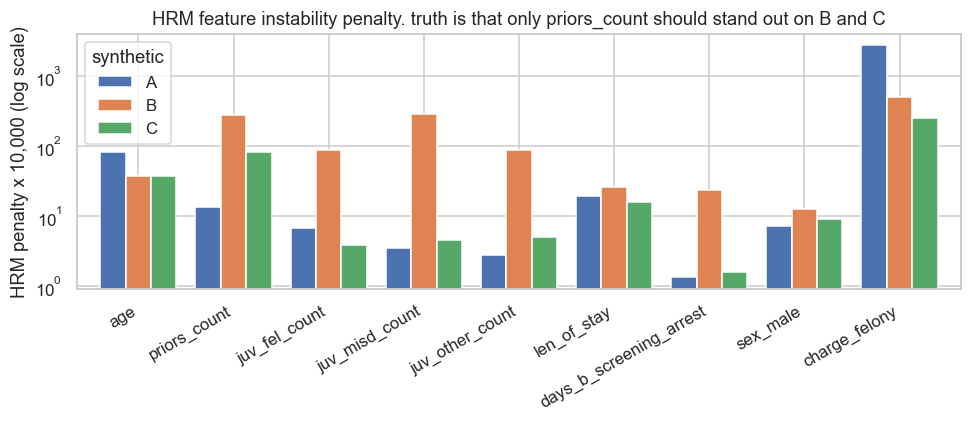

In [8]:
# figure. the penalty table, on a log scale so the blowups and the (missing) priors signal
# are visible at once.
fig, ax = plt.subplots(figsize=(9, 4))
(T * 1e4).plot.bar(ax=ax, width=0.8, color=["#4C72B0", "#DD8452", "#55A868"], logy=True)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("HRM penalty x 10,000 (log scale)")
ax.set_title("HRM feature instability penalty. truth is that only priors_count should stand out on B and C")
ax.legend(title="synthetic")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

In [9]:
# what are the environments made of,
# and where does the charge_felony blowup come from?
y = make_synthetic("B", np.random.default_rng(300)).astype(float)
dom = hrm_frontend(Xs, y, K=3, seed=0, weight=np.ones(len(FEATURES)))

# the same global residuals the backend uses
A_ = np.hstack([Xs, np.ones((len(y), 1))])
resid = A_ @ np.linalg.lstsq(A_, y, rcond=None)[0] - y

print("WHAT ARE HRM'S ENVIRONMENTS MADE OF?  (synthetic B, where the flip is in the under 25s)")
print("=" * 90)
print(f"  the flipped group is {GROUP_B.mean():.0%} of the population.")
print()
print(f"  {'env':>4s} {'n':>6s} {'under 25 share':>15s} {'mean outcome':>13s} "
      f"{'mean resid':>11s} {'mean x_felony':>14s}")
for k in np.unique(dom):
    m = dom == k
    print(f"  {k:>4d} {m.sum():>6d} {GROUP_B[m].mean():>15.1%} {y[m].mean():>13.3f} "
          f"{resid[m].mean():>+11.3f} {Xs[m, FEATURES.index('charge_felony')].mean():>+14.3f}")

WHAT ARE HRM'S ENVIRONMENTS MADE OF?  (synthetic B, where the flip is in the under 25s)
  the flipped group is 22% of the population.

   env      n  under 25 share  mean outcome  mean resid  mean x_felony
     0   2897           30.7%         0.999      -0.443         +0.101
     1   3135           13.4%         0.000      +0.417         -0.113
     2    140           27.1%         0.829      -0.159         +0.432


HRM does not find the flip in the binary setting, and the failure is structural. The assignment
rule compares `|prediction - y|` across candidate models, and with `y` in {0, 1} that comparison is
dominated by the person's own label. The environments end up sorted by outcome, and the backend
penalty then rewards features whose *composition* differs across those environments.

A fair test is to run the identical experiment with a continuous outcome, the setting HRM was
designed for.

In [10]:
# the fair test. same features, same flipped group, but a continuous outcome from a linear
# model, which is exactly HRM's stated setting (LinearRegression + MSELoss)
beta = np.zeros(len(FEATURES))
beta[J] = 1.0
beta[FEATURES.index("age")] = -0.6
# note that sex_male has a true coefficient of exactly zero here. keep an eye on it

def make_regression_world(flip, rng, noise=1.0):
    b = np.tile(beta, (len(df), 1))
    if flip:
        b[GROUP_B, J] = -1.0            # priors flips sign for the under 25s
    return (Xs * b).sum(axis=1) + rng.normal(0, noise, len(df))

print("THE FAIR TEST. HRM on a CONTINUOUS outcome")
print("=" * 84)
for label, flip in [("no flip   (truth is that nothing is unstable)", False),
                    ("priors FLIPS for the under 25s", True)]:
    reps = [pd.Series(hrm(Xs, make_regression_world(flip, np.random.default_rng(100 + r)),
                          K=3, seed=r)["penalty"], index=FEATURES) for r in range(5)]
    P = pd.DataFrame(reps).median()
    rank = int(P.rank(ascending=False)["priors_count"])
    y1 = make_regression_world(flip, np.random.default_rng(100))
    dom1 = hrm_frontend(Xs, y1, K=3, seed=0, weight=np.ones(len(FEATURES)))

    print()
    print(label)
    print(f"  HRM's most unstable feature   {P.idxmax()}")
    print(f"  priors_count penalty          {P['priors_count']:.4f}  (rank {rank} of {len(FEATURES)})")
    print(f"  highest penalty of any other  {P.drop('priors_count').max():.4f}  ({P.drop('priors_count').idxmax()})")
    print(f"  under 25 share of each environment (population rate {GROUP_B.mean():.2f})  "
          f"{[round(float(GROUP_B[dom1 == k].mean()), 2) for k in np.unique(dom1)]}")

THE FAIR TEST. HRM on a CONTINUOUS outcome

no flip   (truth is that nothing is unstable)
  HRM's most unstable feature   sex_male
  priors_count penalty          0.0078  (rank 5 of 9)
  highest penalty of any other  0.3910  (sex_male)
  under 25 share of each environment (population rate 0.22)  [0.21, 0.22, 0.22]

priors FLIPS for the under 25s
  HRM's most unstable feature   sex_male
  priors_count penalty          0.0402  (rank 4 of 9)
  highest penalty of any other  0.5483  (sex_male)
  under 25 share of each environment (population rate 0.22)  [0.23, 0.27, 0.15]


Three things to take from the continuous test.

1. HRM's penalty for `priors_count` does respond to the planted flip (it rises several fold), so the
   backend's invariance signal is real and pointing at the right feature.
2. But the feature HRM ranks as most unstable, in both the flip world and the no flip world, is
   `sex_male`, whose true coefficient is exactly zero. Same composition times residual artifact as
   above. The clustering step creates environments that differ in sex composition, and the penalty
   cannot tell that apart from a varying coefficient.
3. The frontend still does not isolate the flipped group. Every environment sits near the population
   rate of under 25s.

## Part 2. Predictive Heterogeneity

Split the data into environments. Measure how much better Y can be predicted from X within
environments than overall. The survey's quantity is the information X carries about Y within
environments, minus the information X carries about Y overall, maximized over the choice of
partition. Note what the subtraction does. Information that merely tells the environments' base
rates apart is already in the overall term, so a partition only scores for making the X to Y
relationship itself sharper.

1. **Given a split:** The analyst supplies race x age.
2. **Learned, in sample:** Environments learned on all the data (using y), then scored.
3. **Learned, out of sample:** Environments learned on the training fold only, and each test person
   routed to an environment by a classifier that sees only X. To use a
   learned partition on a new defendant you must decide their environment without knowing whether
   they reoffended.

In [11]:
def predictive_heterogeneity(y, partition, n_splits=5, seed=SEED, min_n=100, per_group=False):
    # information gained = (loss using only a base rate) - (loss using a model),
    # computed once globally and once within environments, then differenced.

    partition = pd.Series(np.asarray(partition))
    pg = np.zeros(len(y)); pl = np.zeros(len(y))   # model predictions, global and local
    bg = np.zeros(len(y)); bl = np.zeros(len(y))   # base rates,        global and local

    for tr, te in StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(Xs, y):
        gm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(Xs[tr], y[tr])
        pg[te] = gm.predict_proba(Xs[te])[:, 1]
        bg[te] = y[tr].mean()

        gtr, gte = partition.iloc[tr], partition.iloc[te]
        for g in pd.unique(gte):
            tem, trm = (gte == g).values, (gtr == g).values
            if trm.sum() < min_n or len(np.unique(y[tr][trm])) < 2:
                # group too small to fit. fall back to the global model, which contributes zero.
                pl[np.array(te)[tem]] = pg[np.array(te)[tem]]
                bl[np.array(te)[tem]] = bg[np.array(te)[tem]]
                continue
            lm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(
                Xs[tr][trm], y[tr][trm])
            pl[np.array(te)[tem]] = lm.predict_proba(Xs[te][tem])[:, 1]
            bl[np.array(te)[tem]] = y[tr][trm].mean()

    info_within = log_loss(y, bl) - log_loss(y, pl)
    info_global = log_loss(y, bg) - log_loss(y, pg)
    if per_group:
        return info_within - info_global, pg, pl
    return info_within - info_global

In [12]:
def learn_environments(y, D, K=3, min_frac=0.15, n_iter=20, seed=SEED):
    # learn the split. assign each person to the environment whose model explains them more
    # than that environment's base rate already does. the base rate term matters, because
    # dropping it turns this into plain mixture of experts, which degenerately splits on y
    rng = np.random.default_rng(seed); n = len(y)
    env = rng.integers(0, K, n)
    for _ in range(n_iter):
        models, rates = {}, {}
        for k in range(K):
            m = env == k
            if m.sum() < min_frac * n or len(np.unique(y[m])) < 2:
                continue
            models[k] = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(D[m], y[m])
            rates[k] = y[m].mean()
        if len(models) < 2:
            env = rng.integers(0, K, n); continue     # collapsed, so restart
        G = np.full((n, K), -np.inf)
        for k, mo in models.items():
            p = np.clip(mo.predict_proba(D)[:, 1], 1e-9, 1 - 1e-9)
            q = np.clip(rates[k], 1e-9, 1 - 1e-9)
            G[:, k] = (y*np.log(p) + (1-y)*np.log(1-p)) - (y*np.log(q) + (1-y)*np.log(1-q))
        new = np.argmax(G, axis=1)
        for k in range(K):
            # keep every environment above the size floor by pulling in its best candidates
            if (new == k).sum() < min_frac * n and k in models:
                need = int(min_frac * n) - (new == k).sum()
                cand = [i for i in np.argsort(-G[:, k]) if new[i] != k][:need]
                new[cand] = k
        if (new == env).all():
            break
        env = new
    return env


def PH_in_sample(y, K=3):
    # environments learned on all the data (using y), then scored
    return predictive_heterogeneity(y, learn_environments(y, Xs, K))


def PH_out_of_sample(y, K=3, n_splits=5, seed=SEED):
    # environments learned on the training fold only, with test people routed from X alone
    pg = np.zeros(len(y)); pl = np.zeros(len(y)); bg = np.zeros(len(y)); bl = np.zeros(len(y))
    for tr, te in StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(Xs, y):
        gm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(Xs[tr], y[tr])
        pg[te] = gm.predict_proba(Xs[te])[:, 1]; bg[te] = y[tr].mean()

        env_tr = learn_environments(y[tr], Xs[tr], K)          # learned without the test fold
        router = GradientBoostingClassifier(n_estimators=60, max_depth=3,
                                            random_state=seed).fit(Xs[tr], env_tr)
        env_te = router.predict(Xs[te])                         # routed from X alone

        for k in np.unique(env_te):
            tem, trm = (env_te == k), (env_tr == k)
            if trm.sum() < 100 or len(np.unique(y[tr][trm])) < 2:
                pl[np.array(te)[tem]] = pg[np.array(te)[tem]]
                bl[np.array(te)[tem]] = bg[np.array(te)[tem]]
                continue
            lm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(
                Xs[tr][trm], y[tr][trm])
            pl[np.array(te)[tem]] = lm.predict_proba(Xs[te][tem])[:, 1]
            bl[np.array(te)[tem]] = y[tr][trm].mean()

    return (log_loss(y, bl) - log_loss(y, pl)) - (log_loss(y, bg) - log_loss(y, pg))

PREDICTIVE HETEROGENEITY
         using race x age  learning the split (in sample)  learning the split (out of sample)
dataset                                                                                      
A                  -0.019                           0.594                              -1.733
B                  -0.023                           0.556                              -1.865
C                  -0.022                           0.528                              -1.922
REAL               -0.017                           0.503                              -1.846


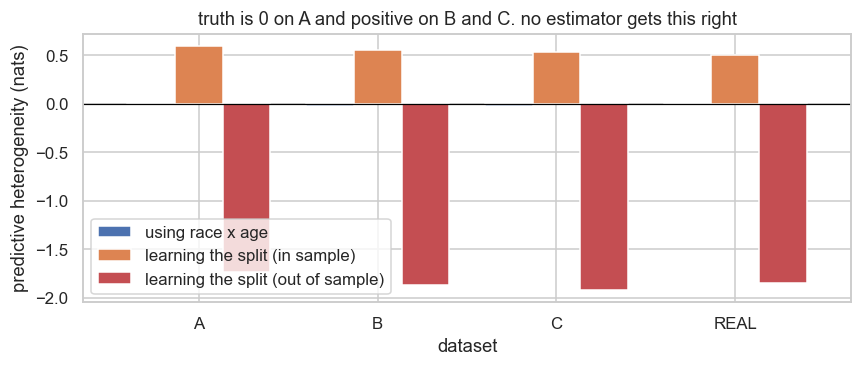

In [13]:
print("PREDICTIVE HETEROGENEITY")
print("=" * 88)
ph_rows = []
for s in ["A", "B", "C", "REAL"]:
    y = y_real if s == "REAL" else make_synthetic(s, np.random.default_rng(555))
    ph_rows.append({
        "dataset": s,
        "using race x age":                   predictive_heterogeneity(y, groups),
        "learning the split (in sample)":     PH_in_sample(y),
        "learning the split (out of sample)": PH_out_of_sample(y),
    })
ph_table = pd.DataFrame(ph_rows).set_index("dataset")
print(ph_table.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
ph_table.plot.bar(ax=ax, width=0.8, color=["#4C72B0", "#DD8452", "#C44E52"])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("predictive heterogeneity (nats)")
ax.set_title("truth is 0 on A and positive on B and C. no estimator gets this right")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [15]:
# the given split column is flat even on B, whose flip sits inside the race x age
# partition (the under 25 cells). is the implementation broken, or is the measure blind?
# drill into B, group by group. log loss of the global model vs the group's own local model

y = make_synthetic("B", np.random.default_rng(555))
_, pg, pl = predictive_heterogeneity(y, groups, per_group=True)

print("SYNTHETIC B, per group. does the group's own model beat the global one?")
print("=" * 88)
gp = pd.Series(np.asarray(groups))
rows = []
for g in sorted(gp.unique()):
    m = (gp == g).values
    rows.append({"group": g, "n": int(m.sum()),
                 "LL_global": log_loss(y[m], pg[m]), "LL_local": log_loss(y[m], pl[m]),
                 "local_gain": log_loss(y[m], pg[m]) - log_loss(y[m], pl[m]),
                 "flipped_cell": "Less than 25" in g})
tab = pd.DataFrame(rows)
print(tab.round(4).to_string(index=False))
print()
print("the local models fire exactly where they should. the biggest gains are in the")
print("under 25 cells, where the flip lives")

SYNTHETIC B, per group. does the group's own model beat the global one?
                             group    n  LL_global  LL_local  local_gain  flipped_cell
        African-American / 25 - 45 1898     0.6125    0.6058      0.0067         False
African-American / Greater than 45  468     0.6191    0.6057      0.0134         False
   African-American / Less than 25  809     0.6520    0.6053      0.0468          True
               Caucasian / 25 - 45 1128     0.6262    0.6292     -0.0030         False
       Caucasian / Greater than 45  628     0.5436    0.5265      0.0170         False
          Caucasian / Less than 25  347     0.6552    0.6154      0.0397          True
                   Other / 25 - 45  506     0.6297    0.6249      0.0048         False
           Other / Greater than 45  197     0.5689    0.5979     -0.0289         False
              Other / Less than 25  191     0.6579    0.6886     -0.0307          True

the local models fire exactly where they should. the bigg

In [27]:
# the learned split scores hugely in sample and collapses out of sample,
# on every dataset including A, where the true value is 0. what is the learner doing?
y = make_synthetic("A", np.random.default_rng(1))          # no heterogeneity in this data
env = learn_environments(y, Xs, K=3)
u = np.unique(env)

print(f"  environment sizes        {[int((env == k).sum()) for k in u]}")
print(f"  recidivism rate in each  {[round(float(y[env == k].mean()), 3) for k in u]}")

tr, te = train_test_split(np.arange(len(y)), test_size=0.3, random_state=SEED, stratify=env)
router = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=SEED).fit(Xs[tr], env[tr])
acc = (router.predict(Xs[te]) == env[te]).mean()
guess = pd.Series(env[te]).value_counts(normalize=True).max()

p_glob = LogisticRegression(max_iter=3000).fit(Xs, y).predict_proba(Xs)[:, 1]
resid = y - p_glob
print(f"  average model residual (actual minus predicted) in each environment  "
      f"{[round(float(resid[env == k].mean()), 3) for k in u]}")
print()
print("  the learner separates people by whether the global model happened to")
print("  over or under predict them. on this dataset that residual is pure noise. sorting")
print("  people by their own residual looks like a large information gain in sample, because")
print("  you have sorted them by the thing you are trying to predict. out of sample it is")
print("  not useful. a new defendant's residual is not knowable from their features, so they")
print("  get routed to the wrong environment's model, and the score becomes negative.")

  environment sizes        [2949, 3223]
  recidivism rate in each  [0.34, 0.556]
  average model residual (actual minus predicted) in each environment  [-0.125, 0.115]

  the learner separates people by whether the global model happened to
  over or under predict them. on this dataset that residual is pure noise. sorting
  people by their own residual looks like a large information gain in sample, because
  you have sorted them by the thing you are trying to predict. out of sample it is
  not useful. a new defendant's residual is not knowable from their features, so they
  get routed to the wrong environment's model, and the score becomes negative.


An environment assignment that depends on Y cannot be routed.
For a new person you do not know Y, so you cannot decide which environment they belong to, so you
cannot deploy the partition, and you cannot cross validate it either. Any partition worth
having must be predictable from X alone.

## Part 3. Relative Regret

How much worse off is each group with the global model than with its own model? Following the
survey, the loss is zero one error and the reported quantity is the ratio of the global model's
error to the group's own error, minus one.

Every prediction is made on held out
folds. And a group is only credited with its own model if that model actually beats the global
one on the held out data (`error_best = min(global, local)`), so estimation noise in small groups
cannot masquerade as regret.

In [21]:
def relative_regret(y, partition, min_n=100, seed=SEED):
    partition = pd.Series(np.asarray(partition))
    pg = np.zeros(len(y)); pl = np.zeros(len(y))
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed).split(Xs, y):
        gm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(Xs[tr], y[tr])
        pg[te] = gm.predict_proba(Xs[te])[:, 1]
        gtr, gte = partition.iloc[tr], partition.iloc[te]
        for g in pd.unique(gte):
            tem, trm = (gte == g).values, (gtr == g).values
            if trm.sum() < min_n or len(np.unique(y[tr][trm])) < 2:
                pl[np.array(te)[tem]] = pg[np.array(te)[tem]]; continue
            lm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(
                Xs[tr][trm], y[tr][trm])
            pl[np.array(te)[tem]] = lm.predict_proba(Xs[te][tem])[:, 1]

    rows = []
    for g in sorted(partition.unique()):
        m = (partition == g).values
        if m.sum() < min_n: continue
        e_glob = ((pg[m] >= .5).astype(int) != y[m]).mean()
        e_best = min(e_glob, ((pl[m] >= .5).astype(int) != y[m]).mean())
        rows.append({"group": g, "n": int(m.sum()), "error_global": e_glob, "error_best": e_best,
                     "relative_regret": e_glob / e_best - 1 if e_best > 0 else 0.0})
    return pd.DataFrame(rows)


print("RELATIVE REGRET on real COMPAS (race x age groups)")
print("=" * 80)
rr = relative_regret(y_real, groups).sort_values("relative_regret", ascending=False)
print(rr.round(3).to_string(index=False))

print()
print("the same measure on the synthetic datasets, so the real numbers have a scale")
print("=" * 80)
rr_syn = {}
for s in ["A", "B", "C"]:
    ys = make_synthetic(s, np.random.default_rng(777))
    r = relative_regret(ys, groups)
    rr_syn[s] = r
    print(f"  synthetic {s}. max regret {r.relative_regret.max():6.1%}   mean {r.relative_regret.mean():6.1%}")
print(f"  REAL COMPAS. max regret {rr.relative_regret.max():6.1%}   mean {rr.relative_regret.mean():6.1%}")

RELATIVE REGRET on real COMPAS (race x age groups)
                             group    n  error_global  error_best  relative_regret
          Caucasian / Less than 25  347         0.346       0.323            0.071
           Other / Greater than 45  197         0.249       0.239            0.043
              Other / Less than 25  191         0.356       0.351            0.015
       Caucasian / Greater than 45  628         0.248       0.245            0.013
        African-American / 25 - 45 1898         0.303       0.303            0.000
African-American / Greater than 45  468         0.321       0.321            0.000
   African-American / Less than 25  809         0.337       0.337            0.000
               Caucasian / 25 - 45 1128         0.352       0.352            0.000
                   Other / 25 - 45  506         0.312       0.312            0.000

the same measure on the synthetic datasets, so the real numbers have a scale
  synthetic A. max regret   0.8%   mean  

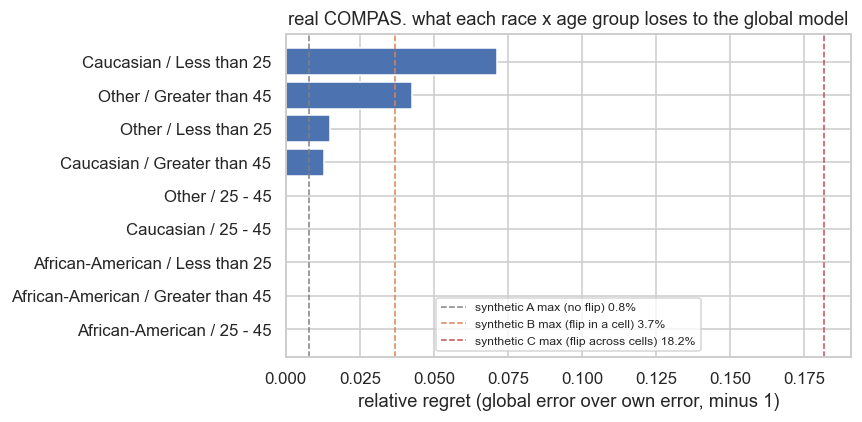

In [22]:
# figure. regret per group on the real data, with the synthetic maxima as reference lines.
fig, ax = plt.subplots(figsize=(8, 4))
rr_plot = rr.sort_values("relative_regret")
ax.barh(rr_plot["group"], rr_plot["relative_regret"], color="#4C72B0")
ax.axvline(rr_syn["A"].relative_regret.max(), color="gray",    ls="--", lw=1,
           label=f"synthetic A max (no flip) {rr_syn['A'].relative_regret.max():.1%}")
ax.axvline(rr_syn["B"].relative_regret.max(), color="#DD8452", ls="--", lw=1,
           label=f"synthetic B max (flip in a cell) {rr_syn['B'].relative_regret.max():.1%}")
ax.axvline(rr_syn["C"].relative_regret.max(), color="#C44E52", ls="--", lw=1,
           label=f"synthetic C max (flip across cells) {rr_syn['C'].relative_regret.max():.1%}")
ax.set_xlabel("relative regret (global error over own error, minus 1)")
ax.set_title("real COMPAS. what each race x age group loses to the global model")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

On the no flip world it stays near the noise floor. It rises on B and
rises a lot on C, ordering the planted heterogeneity correctly. On real COMPAS the worst off group
loses a few percent to the global model and most groups lose exactly nothing, which sits between
the no flip and the planted flip worlds.

One caveat on C. The C flip cuts across race x age, so per cell models capture it only partially.
Regret fires because the flipped people are unevenly spread over the cells, not because the
partition is right. Regret measures whether a partition helps, not whether it is the true one.

This matches the survey's own Figure 5, which reports COMPAS among the benchmarks with small
relative regret. The Y given X relationship largely transfers across these demographic groups, so
COMPAS has little exploitable heterogeneity along them.

## Part 4. Scorecard

Every entry below is a summary of a result computed above in this notebook.

In [23]:
summary = pd.DataFrame([
    {"method": "HRM (binary outcome)",
     "synthetic A (should be silent)": "flags the wrong features",
     "synthetic B (should fire)": "misses priors entirely",
     "verdict": "frontend sorts by the label"},
    {"method": "HRM (continuous outcome)",
     "synthetic A (should be silent)": "flags a zero coefficient feature",
     "synthetic B (should fire)": "priors penalty rises about 5x but ranks mid pack",
     "verdict": "real signal, buried by clustering noise"},
    {"method": "Pred. het. (given split)",
     "synthetic A (should be silent)": "silent",
     "synthetic B (should fire)": "silent, even though local models fire",
     "verdict": "no power at this signal size"},
    {"method": "Pred. het. (in sample)",
     "synthetic A (should be silent)": "large positive (true value = 0)",
     "synthetic B (should fire)": "fires, but so does A",
     "verdict": "overfits its own residuals"},
    {"method": "Pred. het. (out of sample)",
     "synthetic A (should be silent)": "collapses negative",
     "synthetic B (should fire)": "collapses negative",
     "verdict": "learned split is not routable, so not deployable"},
    {"method": "Relative regret",
     "synthetic A (should be silent)": "low",
     "synthetic B (should fire)": "higher, and higher still on C",
     "verdict": "works"},
])
print(summary.to_string(index=False))

                    method   synthetic A (should be silent)                        synthetic B (should fire)                                          verdict
      HRM (binary outcome)         flags the wrong features                           misses priors entirely                      frontend sorts by the label
  HRM (continuous outcome) flags a zero coefficient feature priors penalty rises about 5x but ranks mid pack          real signal, buried by clustering noise
  Pred. het. (given split)                           silent            silent, even though local models fire                     no power at this signal size
    Pred. het. (in sample)  large positive (true value = 0)                             fires, but so does A                       overfits its own residuals
Pred. het. (out of sample)               collapses negative                               collapses negative learned split is not routable, so not deployable
           Relative regret                          